### 1. Load recording.
- Two available recordings.
- One is for venous occlusion, the other for ischemia. 

In [171]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA, FastICA

from utils import load_pickle

dir_path = 'data/'
# filename = 'andrei_arterial_no_hand_position.pickle'
filename = 'anonymized_venous.pickle'
raw_data : np.ndarray = load_pickle(dir_path, filename)
print("Data shape: ", raw_data.shape)

if raw_data.shape[1] != 18:
    print("warning: number of channels is not 18. is this the correct input?")

sample_rate = 25
    

Data shape:  (21063, 18)


### 2. Establish baseline: 
Every measurement is relative to the baseline signal transmitted through the tissue at experiment start.

In [172]:
# Calculate baseline absorbance for each photodiode

baseline_duration = 5
baseline_samples = sample_rate * baseline_duration

# Compute the baseline as the mean of the first 5 seconds of data
baseline = np.mean(raw_data[0:0+baseline_samples, :], axis=0)

# Apply log transformation and baseline correction
variation_data = np.log10(baseline / raw_data) #fix this to handle log of zero (nearly impossible but yea)


/tmp/ipykernel_236519/692268560.py:10: RuntimeWarning: divide by zero encountered in divide
  variation_data = np.log10(baseline / raw_data) #fix this to handle log of zero (nearly impossible but yea)
/tmp/ipykernel_236519/692268560.py:10: RuntimeWarning: invalid value encountered in log10
  variation_data = np.log10(baseline / raw_data) #fix this to handle log of zero (nearly impossible but yea)


### 3. Define data layout relative to physical sensor layout
- Every measurement has 18 samples (9 LED wavelengths x 2 photodiodes active)
- LEDs are split accross two different chips, positioned at different locations on the sensor surface
- There are 4 photodiodes of which only 2 are active for every given measurement
- These arrays define convenient references to index the 18 sample array based on the geometry of the sensor (LED and PD position) as well as the wavelength of the LED
- See Block #5. for use

In [173]:

# these are informations for locating the led/photodiode on the setup by the measurement index
# eg which photodiode is close to which led and which measurements are made on the same photodiode etc
# they are always based off the index in the 18 measurements 

#main physical separation:
#left led bank are the ones with wavelengths ending in _50nm. they match to PD1 and PD3
#right led bank are the ones with wl ending in _00nm. they use PD2 and PD4
left_led_bank = {0, 1, 4, 5, 8, 9, 12, 13, 16, 17} #these are in pairs cos its always gonna be two PD per led
right_led_bank = {2, 3, 6, 7, 10, 11, 14, 15} #saeme as above. also its less cos we only havae 4 here

#secondary physical separation: (each led bank has an upper and lower)
#upper is ppg1 (pd1 and pd3)
#lower is ppg2 (pd2 and pd4)
upper_pd_bank = {0, 2, 4, 6, 8, 10, 12, 14, 16} #pd1 and pd3
lower_pd_bank = {1, 3, 5, 7, 9, 11, 13, 15, 17} #pd2 and pd4

#smallest separation: (leds on a chip might be slower to one of their banks.. annoying but its a limitation)
#upper row has wavelengths [550 - 750] and [600 - 800] and its closer to upper PD bank
#lower row has wl [850 - 950] and [900]
upper_led_row = {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
lower_led_row = {12, 13, 14, 15, 16, 17}
#plottingationtime

#led proximity to PD: possibly useful spatial classification. might be good for pulseoximetry (since path length matters more)
ledrow_near_pdbank = (upper_pd_bank & upper_led_row) | (lower_pd_bank & lower_led_row)
ledrow_far_pdbank = (upper_pd_bank & lower_led_row) | (lower_pd_bank & upper_led_row)


#these are data for matching an index to a wavelength
#wavelengths
wavelengths_values_ordered = [550, 600, 650, 700, 750, 800, 850, 900, 950]
wavelengths_expanded = [wl for wl in wavelengths_values_ordered for _ in range(2)]
index_to_wavelength = {index: wl for index, wl in enumerate(wavelengths_expanded)}


### 4. Absorbance values of studied chromophores
- This section defines the arrays for absorbance of hemoglobin and deoxihemoglobin by wavelength
- These are based off the 20nm FWHM (full width at half maximum) of the LEDS, rather than assuming perfect monochromatic light
- For details on how these data are calculated, check the "spectra" directory in the project
- The "water absorbance" is just based off a series of hand picked constants to approximate the less significant absorbance of water itself. Not used.
- "scattering factor" is a rough correction for the effect of Mie scattering due to cells. Not used.

In [174]:

#these are the absorbance arrays that we will use for determining chromophore concentrations

deoxi_hb_absorbance_vals = [44757.710235, 20404.315993,  3450.521159,  1875.68514,   1298.731924,    862.651699,   700.60939,    748.243303,   594.923346]
oxi_hb_absorbance_vals =   [39933.857941, 13944.703696,  390.720087,   312.671409,   520.939252,    810.847554,  1049.825862,  1188.19433,   1191.995552]


use_water_absorbance = False #this is a flag to enable or disable the water absorbance. 
use_scattering_factor = False #this is a flag to enable or disable the scattering factor. 

if use_water_absorbance:
    water_absorbance_vals = [0.004, 0.010, 0.015, 0.020, 0.030, 0.050, 0.100, 0.250, 0.600, 1.200]
    water_absorbance_vals = [val * 35847.0 for val in water_absorbance_vals]
    #water_absorbance_vals = [-4.00399057e-02, -4.00399057e-02, 2.30455095e-01, 2.30455095e-01, 3.11451444e-01, 3.11451444e-01, 6.06445052e-01, 6.06445052e-01, 6.93188035e-01, 6.93188035e-01]

# (Add or remove points as needed, or clip at 950 if you only go that far.)

#pseudochromophore absorbance values

p = 1.0 #this is the Mie scattering thingy that apparently aint always 1.
scattering_absorbance_vals = [10000.0 / (wl ** p) for wl in wavelengths_values_ordered]
#normalize it to the same val as deoxihgl so you can plot in the same windows
#fact = ratio of magnitudes for vectors pls do it copilot
fact = np.linalg.norm(deoxi_hb_absorbance_vals) / np.linalg.norm(scattering_absorbance_vals)
scattering_absorbance_vals = [val * fact for val in scattering_absorbance_vals]

deoxi_hb_absorbance = {
    wl: absorbance
    for wl, absorbance in zip(wavelengths_values_ordered, deoxi_hb_absorbance_vals)
}

oxi_hb_absorbance = {
    wl: absorbance
    for wl, absorbance in zip (wavelengths_values_ordered, oxi_hb_absorbance_vals)
}

if use_water_absorbance:
    water_absorbance = {
        wl: absorbance
        for wl, absorbance in zip (wavelengths_values_ordered, water_absorbance_vals)
    }

scattering_absorbance = {
    wl: absorbance
    for wl, absorbance in zip(wavelengths_values_ordered, scattering_absorbance_vals)
}

### 5. Pick which LED and Photodiode arrangement to base calculation off
- Given the different path lengths for each Photodiode and LED combination, realistically only some measurements will be "comparable". Pick which LED bank and Photodiode bank will be used for calculations.
- Use diagram below and choose wisely.

```text

        Left LED Bank           Right LED Bank
              │                       │
              ▼                       ▼  
 │           PD1          │          PD3           │    <---- Upper Photodiode Bank
─┼────────────────────────┼────────────────────────┼─
 │       550 650 750      │      600 700 800       │    <---- Upper LED Row
 │       850 950          │      900 1000*         │    <---- Lower LED Row
─┼────────────────────────┼────────────────────────┼─
 │           PD2          │          PD4           │    <---- Lower Photodiode Bank
                   
```

*1000nm is physically disconnected

In [175]:
#selected_indices = sorted(left_led_bank & upper_pd_bank) #default selection
selected_indices = sorted(left_led_bank & upper_pd_bank) #
selected_wavelengths = [index_to_wavelength[index] for index in selected_indices]

print("Selected wavelengths: ", selected_wavelengths)

Selected wavelengths:  [550, 650, 750, 850, 950]


### 6. Create the absorbance matrix

The concentration estimates are obtained by solving the linear system

$\mathbf{M}\mathbf{c}=\mathbf{A},$

where

- $\mathbf{M}$ is the absorbance (extinction coefficient) matrix,
- $\mathbf{c}$ is the vector of unknown chromophore concentrations,
- $\mathbf{A}$ is the vector of measured absorbances.

Since absorbance is measured at 4 or 5 wavelengths (the vector $\mathbf{A}$ has 4 or 5 numbers), while only two chromophores are estimated , the system is overdetermined. Therefore, the chromophore concentrations are obtained using a least-squares method.

In [176]:
#general absorbance matrix
M = np.array([
    [deoxi_hb_absorbance[wl], oxi_hb_absorbance[wl]]
    for wl in selected_wavelengths
])

if use_water_absorbance: #if enabled. might wanna rewrite this as if else
    water_absorbance_temp = [water_absorbance[wl] for wl in selected_wavelengths]
    M = np.column_stack((M, water_absorbance_temp))

if use_scattering_factor: #if enabled. might wanna rewrite this as if else
    scattering_absorbance_temp = [scattering_absorbance[wl] for wl in selected_wavelengths]
    M = np.column_stack((M, scattering_absorbance_temp))




if M.shape[0] != len(selected_indices):
    print("Warning: M matrix has different number of rows than the number of channels in the data")
    #return


### 7. Calculate the cromophore concentrations
- Average data by one second chunks
- Calculate best fit cromophore concentrations per second for the entire data set by solving 

$\mathbf{M}\mathbf{c}=\mathbf{A},$

where

- $\mathbf{M}$ is the absorbance (extinction coefficient) matrix,
- $\mathbf{c}$ is the vector of unknown chromophore concentrations,
- $\mathbf{A}$ is the vector of measured absorbances averaged for a second.

In [177]:
#core logic for determining chromophore concentrations

#averaging per seconds (too much data, no reason to do this at 25hz)
num_samples, num_channels = variation_data.shape

num_full_seconds = num_samples // sample_rate
truncated_variation_data = variation_data[:num_full_seconds * sample_rate, :]
truncated_variation_data_reshaped = truncated_variation_data.reshape(num_full_seconds, sample_rate, num_channels)
averaged_variation = np.mean(truncated_variation_data_reshaped, axis=1)

#setup output arrays
c_hb = np.zeros(num_full_seconds)
c_hbo2 = np.zeros(num_full_seconds)
if use_water_absorbance:
    c_water = np.zeros(num_full_seconds)
if use_scattering_factor:
    c_scattering = np.zeros(num_full_seconds)
c_hgl_total = np.zeros(num_full_seconds)
c_fake = np.zeros(num_full_seconds)

#this contains the residual norms. this is the difference between the measured absorbance and the "fit" absorbance
residual_norms = np.zeros(num_full_seconds) 

#leftover matrix to attempt to find the proper correction factor
#this can be used to find a pattern to create a correction factor OR to predict what relevant cromophores are missing from the model (eg water, scattering, etc)
leftover_matrix = np.zeros((num_full_seconds, len(selected_indices)))

for t in range(num_full_seconds):
    #get the absorbance values for this second
    A_t = averaged_variation[t, selected_indices]

    #solve for the chromophore concentrations
    try:
        c, residuals, rank, s = np.linalg.lstsq(M, A_t, rcond=None)
        c_hb[t] = c[0]
        c_hbo2[t] = c[1]
        if use_water_absorbance:
            c_water[t] = c[2]
        if use_scattering_factor:
            if use_water_absorbance:
                c_scattering[t] = c[3]
            else:
                c_scattering[t] = c[2]
        
        #this is useful for sanity checking.
        #in ischemia experiments should be roughly constant ("nothing is getting in or out")
        #in occlusion it should slowly increase as blood pools in the tissue
        c_hgl_total[t] = c[0] + c[1]

        #not very useful visually. differences between concentrations. i called it c_fake cos c_diff means sth else to doctors XD
        c_fake[t] = c[0] - c[1] #maybe take abs? 

        # compute residual norm manually
        fit = M @ c
        leftover = A_t - fit
        leftover_matrix[t] = leftover
        residual_norms[t] = np.linalg.norm(leftover) # chatgpt said flip signs but whatevre
        # if t % 30 == 0: #debug print
        #     print(f"Second {t}: Left={leftover}")
        #     pass

    except np.linalg.LinAlgError:
    #shouldnt happen as long as absorbtion spectra are linearly independent. 
        print(f"LinAlgError at interval {t}: {A_t}")
        c_hb[t] = 0
        c_hbo2[t] = 0
        if use_water_absorbance:
            c_water[t] = 0
        c_hgl_total[t] = 0
        c_fake[t] = 0
        residual_norms[t] = np.nan

### 8. Analyze deviation from theoretical model
- Find deviations between the observed absorbances and the best fit models
- PCA finds the largest deviations from observation, as orthogonal vectors
- ICA finds contributions to the error that are independent

In [178]:


#analyzing leftovers
tryPca = True
if tryPca:
    print()
    print("PCA: ")
    pca = PCA(n_components=3)
    pca.fit(leftover_matrix)
    print("Components ", pca.components_)
    print("Explained variance ", pca.explained_variance_)
    print("Explained variance ratio ", pca.explained_variance_ratio_)
    print("Singular values ", pca.singular_values_)
    print("Mean ", pca.mean_)
    # print(pca.noise_variance_)
    # print(pca.n_components_)
    # print(pca.n_features_)
    # print(pca.n_samples_)

tryIca = True
if tryIca:
    ica = FastICA(n_components=2)
    ica.fit(leftover_matrix)
    print()
    print("ICA: ")
    print("Components ", ica.components_)
    print("Mixing ", ica.mixing_)
    print("Mean ", ica.mean_)
    # print(ica.whiten_)
    # print(ica.w_init_)
    # print(ica.tol_)
    # print(ica.max_iter_)
    # print(ica.algorithm_)
    # print(ica.fun_)
    # print(ica.n_components_)
    # print(ica.n_features_)
    # print(ica.n_samples_)





PCA: 
Components  [[-4.28503613e-02  1.81706089e-01  3.52272248e-01  6.02194831e-01
   6.91673617e-01]
 [-4.75904853e-04 -2.09891739e-03 -1.14283074e-01  7.77601762e-01
  -6.18280071e-01]
 [ 2.55748056e-03 -3.01800344e-01  9.01868097e-01 -1.00644319e-01
  -2.92257879e-01]]
Explained variance  [3.31441440e-03 8.03812943e-07 1.79787967e-07]
Explained variance ratio  [9.99703323e-01 2.42448401e-04 5.42281701e-05]
Singular values  [1.66955758 0.02600013 0.01229641]
Mean  [-0.0025559   0.01092032  0.0207871   0.03572924  0.04149505]

ICA: 
Components  [[-3.16656941e-01 -3.09032640e+00 -1.24667860e+02  8.34558196e+02
  -6.68914921e+02]
 [-8.58181977e-01  2.43117473e+00 -2.76236229e+01  2.38247591e+02
  -1.69805705e+02]]
Mixing  [[ 0.00064775 -0.00237886]
 [-0.00275032  0.01008653]
 [-0.0054273   0.01952872]
 [-0.00843662  0.03361274]
 [-0.01099683  0.03825115]]
Mean  [-0.0025559   0.01092032  0.0207871   0.03572924  0.04149505]


### 9. Plot all the results
- Choose what to plot then plot

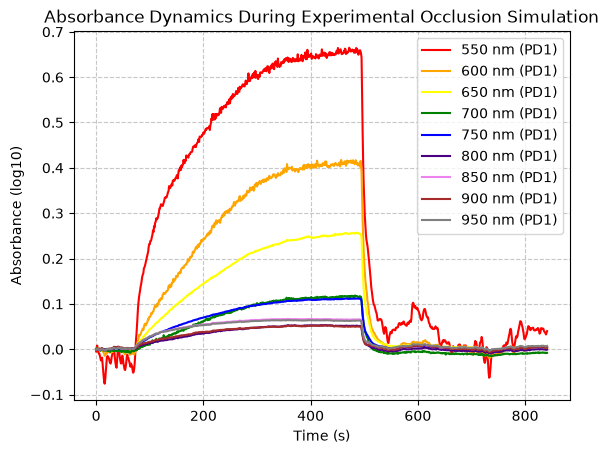

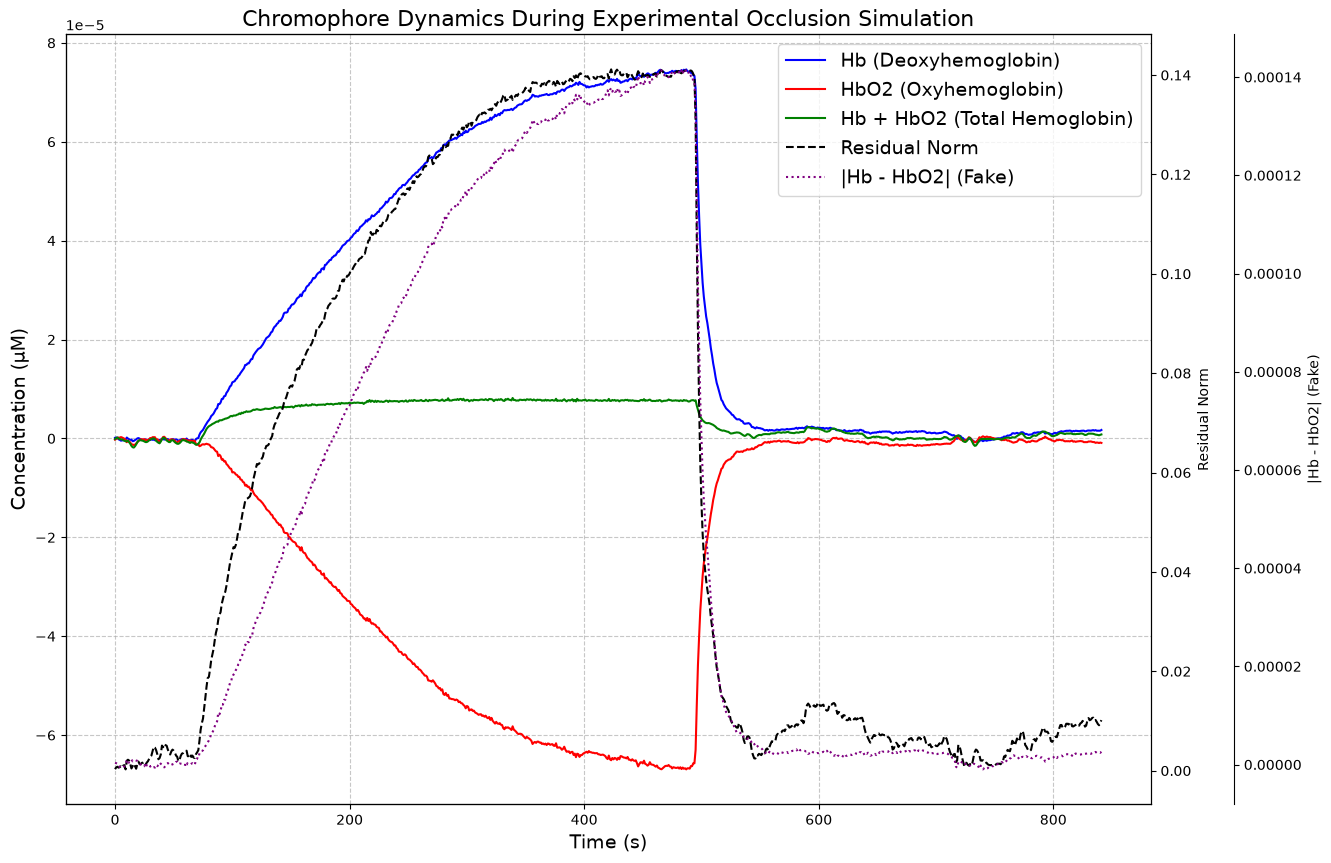

In [179]:

#plotting
plotAbsorbances = True
plotResiduals = True
plotDifference = plotResiduals

# Define colors for each wavelength (rainbow colors in order)
colors = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'violet', 'brown', 'grey']

#this is just for labelling the plot. 
#wavelengths_labels_plot = [550, 600, 650, 700, 750, 800, 850, 900, 950]

index_to_color = {
    index: color 
    for index, color in enumerate([col for col in colors for _ in range(2)])
}

#new plot codestyle
#select which bank to plot
bank_to_plot = left_led_bank
photodiode_to_plot = upper_pd_bank #this is the one that is used for the pulseoximetry

if plotAbsorbances:
    #plt.figure(figsize=(14, 10))
    for i in range(len(variation_data[0])):
        #select which to plot based off this an that
        if not i in photodiode_to_plot:
        #if not i in bank_to_plot:
            continue

        #get color
        color = index_to_color[i]

        #get style
        line_style = None
        line_marker = None
        if i in upper_pd_bank:
            line_style, line_marker = "-", None
        elif i in lower_pd_bank:
            line_style, line_marker = "--", "^"

#     plt.plot(variation_data[:, 2 * i + 1], color=colors[i], linestyle='--', marker='^', 
        plt.plot(averaged_variation[:,i],
                color = color, linestyle = line_style, marker = line_marker, markersize=4, markevery=300,
                label=f'{wavelengths_expanded[i]} nm (PD{i % 2 + 1})')


    # Labeling the plot
    # plt.xlabel('Timp (s)')
    plt.xlabel('Time (s)')
    # plt.ylabel('Absorbanța (log10)')
    plt.ylabel('Absorbance (log10)')
    #plt.title('Recording: ' + filename)
    # plt.title('Dinamica absorbanței în timpul simulării experimentale de ocluzie')
    plt.title('Absorbance Dynamics During Experimental Occlusion Simulation')
    plt.legend()

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig('../figures/plot_absorbance.png', dpi=300)

    plt.show()

fig, ax1 = plt.subplots()
#fig, ax1 = plt.subplots(figsize=(24, 10))

# # Plot the data
# l1 = ax1.plot(c_hb, color='blue', label='Hb (Deoxihemoglobină)')
# l2 = ax1.plot(c_hbo2, color='red', label='HbO2 (Oxihemoglobină)')
# l3 = ax1.plot(c_hgl_total, color='green', label='Hb + HbO2 (Hemoglobină totală)')
l1 = ax1.plot(c_hb, color='blue', label='Hb (Deoxyhemoglobin)')
l2 = ax1.plot(c_hbo2, color='red', label='HbO2 (Oxyhemoglobin)')
l3 = ax1.plot(c_hgl_total, color='green', label='Hb + HbO2 (Total Hemoglobin)')

if use_water_absorbance:
    # lw = ax1.plot(c_water, color='cyan', label='Apă')
    lw = ax1.plot(c_water, color='cyan', label='Water')

if use_scattering_factor:
    # ls = ax1.plot(c_scattering, color='yellow', label='Factor de dispersie')
    ls = ax1.plot(c_scattering, color='yellow', label='Scattering Factor')

# Add labels and title with increased font size
# ax1.set_xlabel('Timp (s)')
# ax1.set_ylabel('Concentrație (μM)')
# ax1.set_title('Dinamica cromoforilor în timpul simulării experimentale de ocluzie')
ax1.set_xlabel('Time (s)', fontsize=14)
ax1.set_ylabel('Concentration (μM)', fontsize=14)
ax1.set_title('Chromophore Dynamics During Experimental Occlusion Simulation', fontsize=16)
ax1.tick_params(axis='both', which='major')

ax1.grid(True, linestyle='--', alpha=0.7)

if plotResiduals:
    ax2 = ax1.twinx()
    # l4 = ax2.plot(residual_norms, color='black', label='Norma reziduurilor', linestyle='--')
    # ax2.set_ylabel('Norma reziduurilor')
    l4 = ax2.plot(residual_norms, color='black', label='Residual Norm', linestyle='--')
    ax2.set_ylabel('Residual Norm')
    ax2.tick_params(axis='both', which='major')

if plotDifference:
    ax3 = ax1.twinx()
    l5 = ax3.plot(c_fake, color='purple', label='|Hb - HbO2| (Fake)', linestyle=':')
    ax3.set_ylabel('|Hb - HbO2| (Fake)')
    ax3.tick_params(axis='both', which='major')
    # Offset the right spine of ax3.  The ticks and label have already been
    # placed on the right by twinx above.
    ax3.spines['right'].set_position(('outward', 60))  # 60 points outwards

# Combine the legends
lines = l1 + l2 + l3
if plotResiduals:
    lines += l4 + l5
if use_water_absorbance:
    lines += lw
if use_scattering_factor:
    lines += ls
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=14)

plt.gcf().set_size_inches(14, 10)

# Save the plot
plt.savefig('../figures/plot_spectrophotometry.png', dpi=300)

# Show the plot
plt.show()

### 10. Plot ICA and PCA results
Note that this can be used to include chromophores in the original model. To do this, the same pattern/component has to be observed accorss many samples and the effect has to be attributed to a plausible factor (Mie scattering, water, etc. see #4)

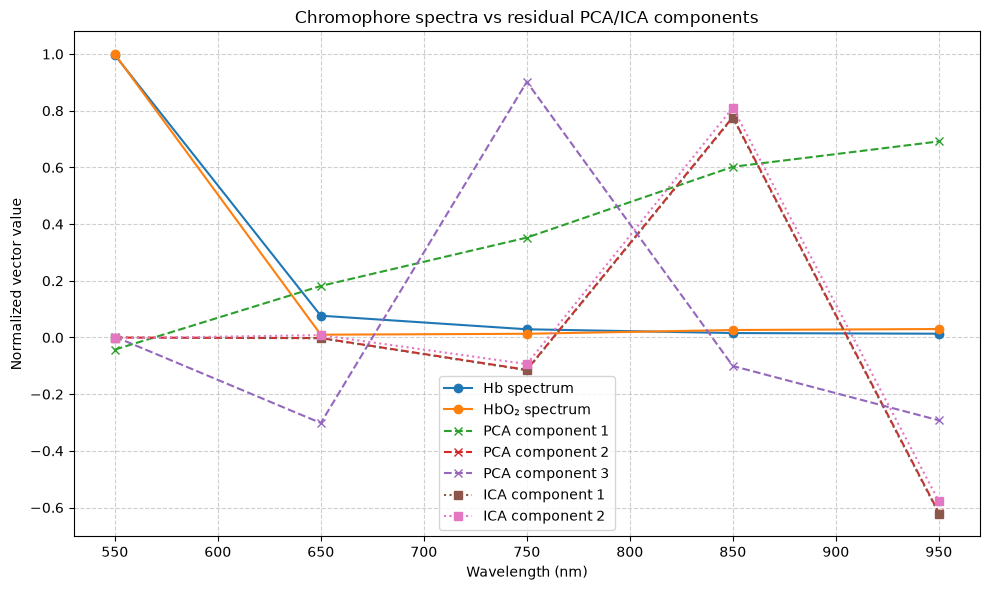

In [180]:
plot_ica = True
plot_pca = True

def normalize_vector(v):
    v = np.array(v, dtype=float)
    return v / np.linalg.norm(v)


# Wavelengths used in the least-squares fit
x = selected_wavelengths

# Chromophore basis vectors for selected wavelengths
hb_vec = np.array([deoxi_hb_absorbance[wl] for wl in selected_wavelengths])
hbo2_vec = np.array([oxi_hb_absorbance[wl] for wl in selected_wavelengths])

plt.figure(figsize=(10, 6))

plt.plot(x, normalize_vector(hb_vec), marker="o", label="Hb spectrum")
plt.plot(x, normalize_vector(hbo2_vec), marker="o", label="HbO₂ spectrum")

if tryPca and plot_pca:
    for i, comp in enumerate(pca.components_):
        plt.plot(x, normalize_vector(comp), marker="x", linestyle="--", label=f"PCA component {i+1}")

if tryIca and plot_ica:
    for i, comp in enumerate(ica.components_):
        plt.plot(x, normalize_vector(comp), marker="s", linestyle=":", label=f"ICA component {i+1}")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized vector value")
plt.title("Chromophore spectra vs residual PCA/ICA components")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig('../figures/plot_residuals.png', dpi=300)
plt.show()